# Đề bài

### Đề bài: Bộ phận Chăm sóc khách hàng và Marketing của sàn Ecommerce đang chuẩn bị cho chương trình Tri ân cuối năm. Tuy nhiên, ngân sách quà tặng có hạn. Giám đốc Marketing yêu cầu bạn:
"Hãy phân loại tập khách hàng của chúng ta thành 3 nhóm A, B, C dựa trên tổng lợi nhuận mà họ mang lại. Tôi muốn tập trung 80% ngân sách quà tặng VIP cho nhóm khách hàng quan trọng nhất và tìm hiểu xem họ là ai (thu nhập, nghề nghiệp như thế nào)."

Nhiệm vụ: Phân tích và trả lời các câu hỏi
- Nhóm A chỉ chiếm bao nhiêu % trong tổng số lượng khách hàng? (Có tuân theo quy luật Pareto không?)
- Nếu công ty chỉ có 500 suất quà đặc biệt, danh sách khách hàng nhóm A có vượt quá số lượng này không?
- Dựa vào thông tin thu nhập và nghề nghiệp, bạn có đề xuất gì cho chiến dịch Marketing sắp tới để thu hút thêm nhiều khách hàng "Nhóm A" mới?


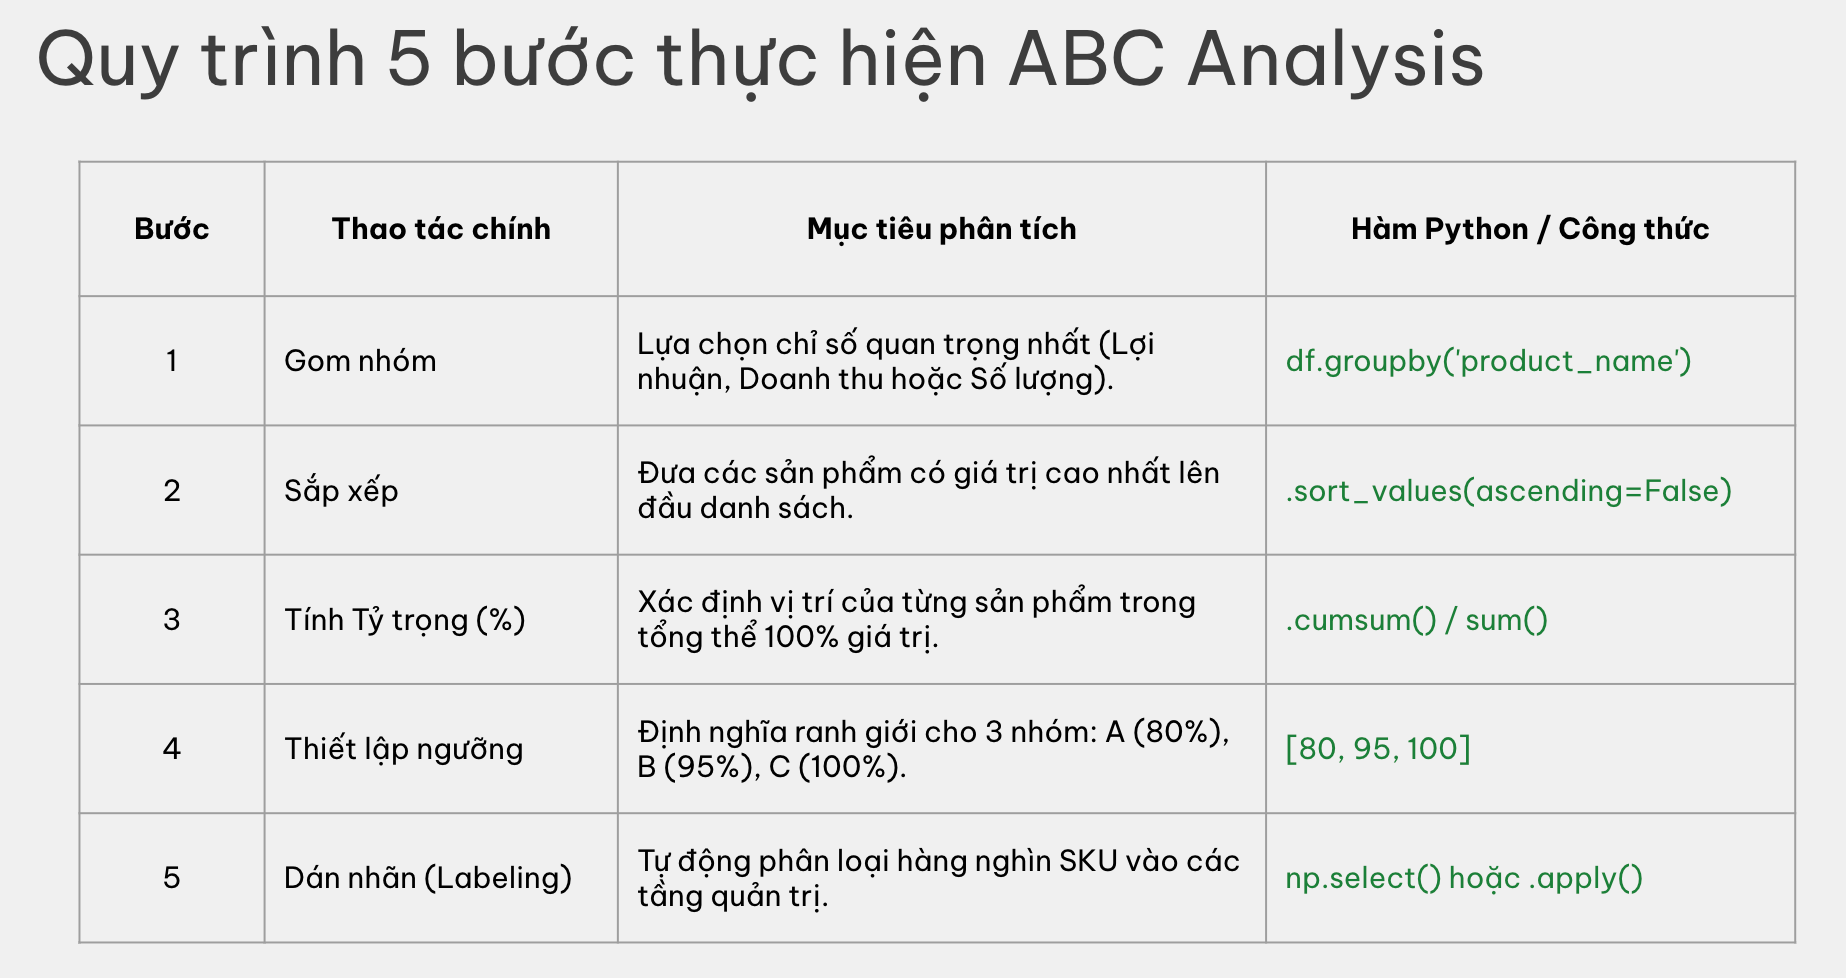

# 1. Import library & data

In [ ]:
# Data Processing
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Datetime Standardize
import datetime

In [ ]:
!python --version

Python 3.13.16


In [ ]:
import sys
import matplotlib

print(f"Python version: {sys.version.split()[0]}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"numpy version: {np.__version__}")

Python version: 3.13.16
pandas version: 2.2.3
matplotlib version: 3.10.0
numpy version: 2.1.3


In [ ]:
sales = pd.read_csv('/content/drive/MyDrive/Khoá Project Analytics/DATASET/BTVN 4/EcomSales.csv')
product = pd.read_csv('/content/drive/MyDrive/Khoá Project Analytics/DATASET/BTVN 4/Product.csv')
customer = pd.read_csv('/content/drive/MyDrive/Khoá Project Analytics/DATASET/BTVN 4/Customer.csv')
region = pd.read_csv('/content/drive/MyDrive/Khoá Project Analytics/DATASET/BTVN 4/Region.csv')

print('Dữ liệu okila')

Dữ liệu okila


#2. Data Checking

In [ ]:
# @title
def check_dataframe(
    df: pd.DataFrame, df_name: str = "DataFrame", outlier_threshold: float = 1.5
) -> None:
    """Kiểm tra tổng thể một DataFrame bao gồm Metadata, Duplicates, NA, và Outliers."""
    print("=" * 60)
    print(f"KIỂM TRA: {df_name.upper()}")
    print("=" * 60)

    # 1. Metadata & Data Types
    if df.empty:
        print("- CẢNH BÁO: DataFrame hiện tại đang rỗng (0 rows).")
        print("=" * 60)
        return

    print(f"- Shape: {df.shape[0]} hàng x {df.shape[1]} cột\n")

    type_na_df = pd.DataFrame(
        {
            "Data Type": df.dtypes,
            "Non-Null Count": df.notnull().sum(),
            "Null Count": df.isnull().sum(),
            "Null Ratio (%)": (df.isnull().sum() / len(df) * 100).round(2),
            "N-Unique": df.nunique(),
        }
    )
    print(type_na_df)

    # 2. Duplicate Check
    print("\n" + "-" * 40)
    print("DUPLICATE CHECK")
    print("-" * 40)
    num_duplicates = df.duplicated().sum()
    dup_percent = (num_duplicates / len(df)) * 100
    print(
        f"- Số dòng trùng lặp hoàn toàn: {num_duplicates} ({dup_percent:.2f}%)"
    )

    # 3. Missing Values Summary
    print("\n" + "-" * 40)
    print("MISSING VALUES (NA) SUMMARY")
    print("-" * 40)
    cols_with_na = type_na_df[type_na_df["Null Count"] > 0]
    if cols_with_na.empty:
        print("- Không có cột nào bị thiếu dữ liệu (NA).")
    else:
        print(cols_with_na[["Null Count", "Null Ratio (%)"]])

    # 4. Outliers Check (IQR Method)
    print("\n" + "-" * 40)
    print("OUTLIERS CHECK (IQR Method)")
    print("-" * 40)
    num_cols = df.select_dtypes(include=[np.number]).columns

    if len(num_cols) == 0:
        print("- Không tìm thấy cột dạng số để kiểm tra outlier.")
    else:
        outlier_summary = []
        for col in num_cols:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1

            # Bỏ qua nếu IQR = 0 (ví dụ cột toàn hằng số hoặc ID)
            if iqr == 0:
                continue

            lower_bound = q1 - outlier_threshold * iqr
            upper_bound = q3 + outlier_threshold * iqr

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][
                col
            ]
            count_outliers = len(outliers)

            if count_outliers > 0:
                outlier_summary.append(
                    {
                        "Column": col,
                        "Outlier Count": count_outliers,
                        "Outlier Ratio (%)": round(
                            (count_outliers / len(df)) * 100, 2
                        ),
                        "Lower Bound": round(lower_bound, 2),
                        "Upper Bound": round(upper_bound, 2),
                        "Min Value": round(df[col].min(), 2),
                        "Max Value": round(df[col].max(), 2),
                    }
                )

        if outlier_summary:
            outlier_df = pd.DataFrame(outlier_summary).set_index("Column")
            print(outlier_df)
        else:
            print("- Không phát hiện outlier nào ở các cột dạng số.")

    print("=" * 60 + "\n")

check_dataframe(ecom_sales, "Ecom Sales")
check_dataframe(product, "Product")
check_dataframe(customer, "Customer")
check_dataframe(region, "Region")

KIỂM TRA: ECOM SALES
- Shape: 51290 hàng x 11 cột

            Data Type  Non-Null Count  Null Count  Null Ratio (%)  N-Unique
RowID           int64           51290           0             0.0     51290
OrderID        object           51290           0             0.0     25728
OrderDate      object           51290           0             0.0      1430
CustomerID     object           51290           0             0.0     17415
Segment        object           51290           0             0.0         3
RegionCode     object           51290           0             0.0      3829
ProductCode    object           51290           0             0.0      3578
Quantity        int64           51290           0             0.0        20
Sales           int64           51290           0             0.0       997
Discount      float64           51290           0             0.0        27
Profit        float64           51290           0             0.0      3822

------------------------------------

#3. Exploratory D.A

In [ ]:
sales.head(2)

,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,Profit
0,25221,IN-2012-TH211151-41003,4/4/2020,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,208.0
1,29464,ID-2013-BD116051-41518,9/1/2021,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,10.0


In [ ]:
product.head(2)

,ProductCode,Product,Category,Subcategory
0,P000001,Soap & Glory Endless Glove Moisturizing Hand C...,Body care,"bath oils, bubbles and soaks"
1,P000002,Pantene Pro-V Truly Relaxed Hair Lightweight C...,Body care,"bath oils, bubbles and soaks"


In [ ]:
customer.head(2)

,CustomerID,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,EducationLevel,Occupation,HomeOwner
0,TH-211151,Jon,Huang,6/18/1962,M,M,jon24@hotmail.com,90000,Bachelors,Professional,Y
1,BD-116051,Eugene,Torres,6/16/1985,S,M,eugene10@hotmail.com,60000,Bachelors,Professional,N


In [ ]:
region.head(2)

,RegionCode,City,State,Country,Countrylatitude,Countrylongitude,Region,Market
0,R0001,Jalalabad,Nangarhar,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific
1,R0002,Herat,Hirat,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific


#4. ABC Analysis

In [ ]:
# 1. Merge file và gom nhóm khách hàng, sắp xếp theo Lợi nhuận (Profit)
df_merged = sales.merge(customer, on='CustomerID', how='left')

df_customer = (
    df_merged.groupby('CustomerID', as_index=False)
    .agg({'Sales': 'sum', 'Profit': 'sum'})
    .sort_values(by='Profit', ascending=False)
    .reset_index(drop=True)
)

# 2. Tính tỷ trọng Lợi nhuận (Profit) và % lũy kế
df_customer['Profit_Share'] = df_customer['Profit'] / df_customer['Profit'].sum()
df_customer['Cum_Profit_Share'] = df_customer['Profit_Share'].cumsum()

# 3. Phân loại ABC khách hàng
conditions = [
    df_customer['Cum_Profit_Share'] <= 0.80,
    df_customer['Cum_Profit_Share'] <= 0.95
]
choices = ['A', 'B']

df_customer['ABC_Group'] = np.select(conditions, choices, default='C')

# Kiểm tra kết quả
df_customer


,CustomerID,Sales,Profit,Profit_Share,Cum_Profit_Share,ABC_Group
0,AR-1082564,5938,2625.30,0.002464,0.002464,A
1,LS-172001402,7351,2429.40,0.002280,0.004744,A
2,MY-1829527,5265,2165.00,0.002032,0.006776,A
3,ML-73952,4522,2156.00,0.002024,0.008800,A
4,YS-2188093,4443,2095.90,0.001967,0.010767,A
...,...,...,...,...,...,...
17410,KB-658568,2548,-1528.80,-0.001435,1.007040,C
17411,PC-1874588,3784,-1642.48,-0.001542,1.005499,C
17412,AJ-78095,5717,-1714.20,-0.001609,1.003890,C
17413,AH-690147,3559,-1989.40,-0.001867,1.002023,C


In [ ]:
# Thông tin khách hàng nhóm A
# 4. Merge thêm các thông tin cá nhân của khách hàng vào bảng df_customer
df_customer_final = df_customer.merge(
    customer[['CustomerID', 'Gender', 'AnnualIncome', 'Occupation']],
    on='CustomerID',
    how='left'
)

df_customer_final

,CustomerID,Sales,Profit,Profit_Share,Cum_Profit_Share,ABC_Group,Gender,AnnualIncome,Occupation
0,AR-1082564,5938,2625.30,0.002464,0.002464,A,F,40000,Skilled Manual
1,LS-172001402,7351,2429.40,0.002280,0.004744,A,F,70000,Skilled Manual
2,MY-1829527,5265,2165.00,0.002032,0.006776,A,M,30000,Clerical
3,ML-73952,4522,2156.00,0.002024,0.008800,A,F,10000,Clerical
4,YS-2188093,4443,2095.90,0.001967,0.010767,A,M,90000,Professional
...,...,...,...,...,...,...,...,...,...
17410,KB-658568,2548,-1528.80,-0.001435,1.007040,C,M,50000,Skilled Manual
17411,PC-1874588,3784,-1642.48,-0.001542,1.005499,C,M,20000,Clerical
17412,AJ-78095,5717,-1714.20,-0.001609,1.003890,C,M,130000,Professional
17413,AH-690147,3559,-1989.40,-0.001867,1.002023,C,F,20000,Manual


#5. Trực quan hoá

/tmp/ipykernel_532/2459680281.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


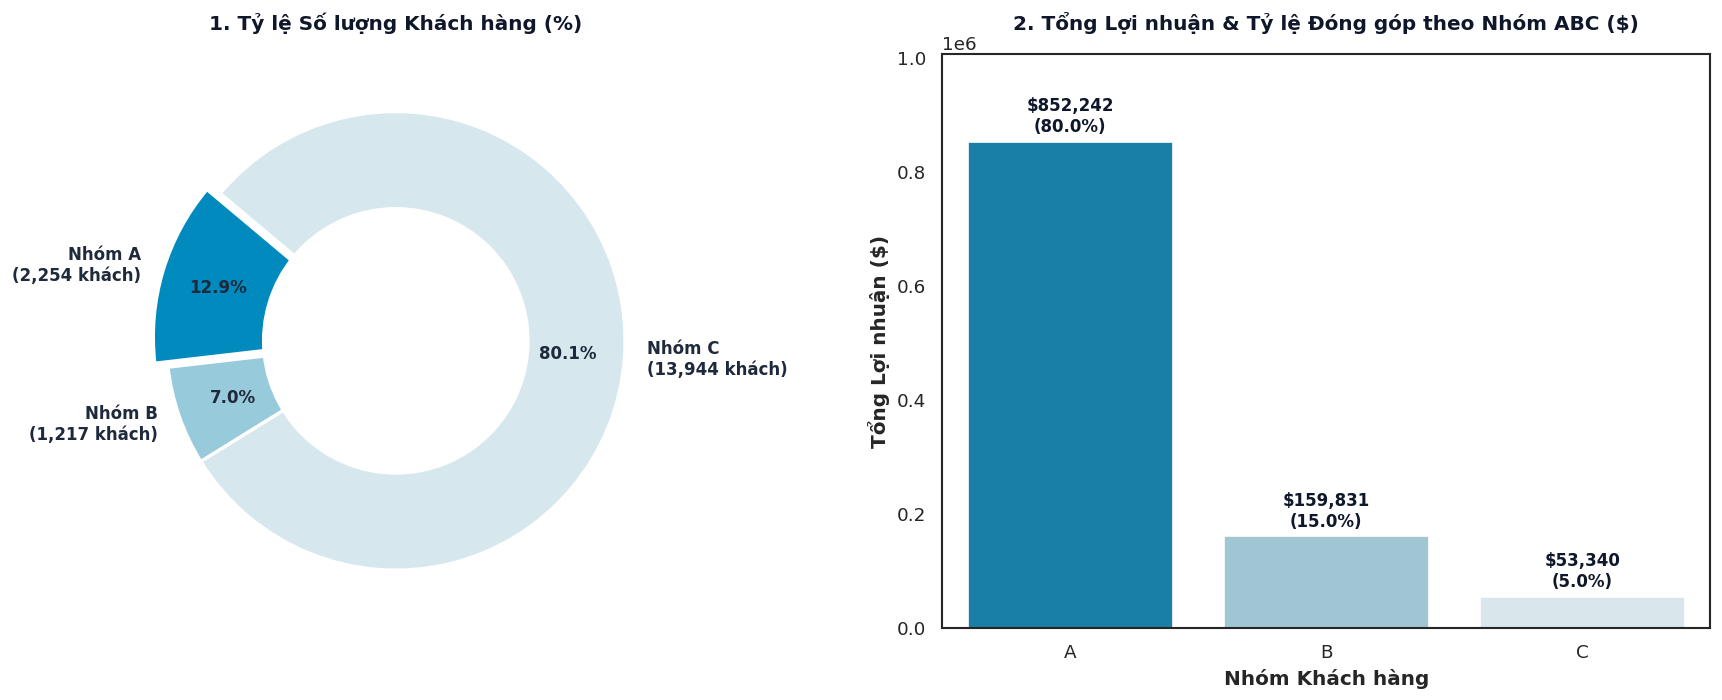

In [ ]:
# @title
# Tỷ lệ và tổng đóng góp của các nhóm
# 1. Thống kê Số lượng Khách hàng & Lợi nhuận theo từng nhóm ABC
abc_summary = (
    df_customer.groupby('ABC_Group', as_index=False)
    .agg(
        Customer_Count=('CustomerID', 'count'),
        Total_Profit=('Profit', 'sum'),
        Total_Sales=('Sales', 'sum')
    )
)

# Đảm bảo đúng thứ tự A -> B -> C
abc_summary['ABC_Group'] = pd.Categorical(abc_summary['ABC_Group'], categories=['A', 'B', 'C'], ordered=True)
abc_summary = abc_summary.sort_values('ABC_Group').reset_index(drop=True)

# Tính tỷ lệ % Khách hàng và % Lợi nhuận
total_customers = abc_summary['Customer_Count'].sum()
total_profit = abc_summary['Total_Profit'].sum()

abc_summary['Cust_Pct'] = (abc_summary['Customer_Count'] / total_customers) * 100
abc_summary['Profit_Pct'] = (abc_summary['Total_Profit'] / total_profit) * 100
abc_summary['Avg_Profit_Per_Cust'] = abc_summary['Total_Profit'] / abc_summary['Customer_Count']

# Trích xuất dữ liệu riêng của Nhóm A
count_A = abc_summary.loc[abc_summary['ABC_Group'] == 'A', 'Customer_Count'].values[0]
pct_A = abc_summary.loc[abc_summary['ABC_Group'] == 'A', 'Cust_Pct'].values[0]
profit_pct_A = abc_summary.loc[abc_summary['ABC_Group'] == 'A', 'Profit_Pct'].values[0]
profit_A = abc_summary.loc[abc_summary['ABC_Group'] == 'A', 'Total_Profit'].values[0]

# 3. Trực quan hóa dữ liệu (2 Biểu đồ song song)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

colors = ['#018ABE', '#97CADB', '#D6E8EE']
explode = (0.06, 0, 0)

# --- CHART 1: Donut Chart - Tỷ lệ Số lượng Khách hàng (%) ---
axes[0].pie(
    abc_summary['Customer_Count'],
    labels=[f"Nhóm {g}\n({c:,} khách)" for g, c in zip(abc_summary['ABC_Group'], abc_summary['Customer_Count'])],
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=140,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 10, 'color': '#1E293B', 'weight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0, 0), 0.58, fc='white')
axes[0].add_artist(centre_circle)
axes[0].set_title('1. Tỷ lệ Số lượng Khách hàng (%)', fontsize=12, weight='bold', pad=15, color='#0F172A')

# --- CHART 2: Bar Chart - Tổng Lợi nhuận & Tỷ lệ đóng góp (%) ---
bars = sns.barplot(
    data=abc_summary,
    x='ABC_Group',
    y='Total_Profit',
    palette=colors,
    ax=axes[1]
)

axes[1].set_title('2. Tổng Lợi nhuận & Tỷ lệ Đóng góp theo Nhóm ABC ($)', fontsize=12, weight='bold', pad=15, color='#0F172A')
axes[1].set_xlabel('Nhóm Khách hàng', weight='bold')
axes[1].set_ylabel('Tổng Lợi nhuận ($)', weight='bold')

# Điều chỉnh trục Y cao hơn để hiển thị nhãn số liệu không bị tràn
axes[1].set_ylim(0, abc_summary['Total_Profit'].max() * 1.18)

# Thêm Data Labels (Tổng Lợi nhuận + Tỷ lệ %) trên đỉnh mỗi cột
for p, pct in zip(bars.patches, abc_summary['Profit_Pct']):
    height = p.get_height()
    axes[1].annotate(
        f'${height:,.0f}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 4), textcoords='offset points',
        fontsize=10, weight='bold', color='#0F172A'
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_532/1096323576.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_532/1096323576.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


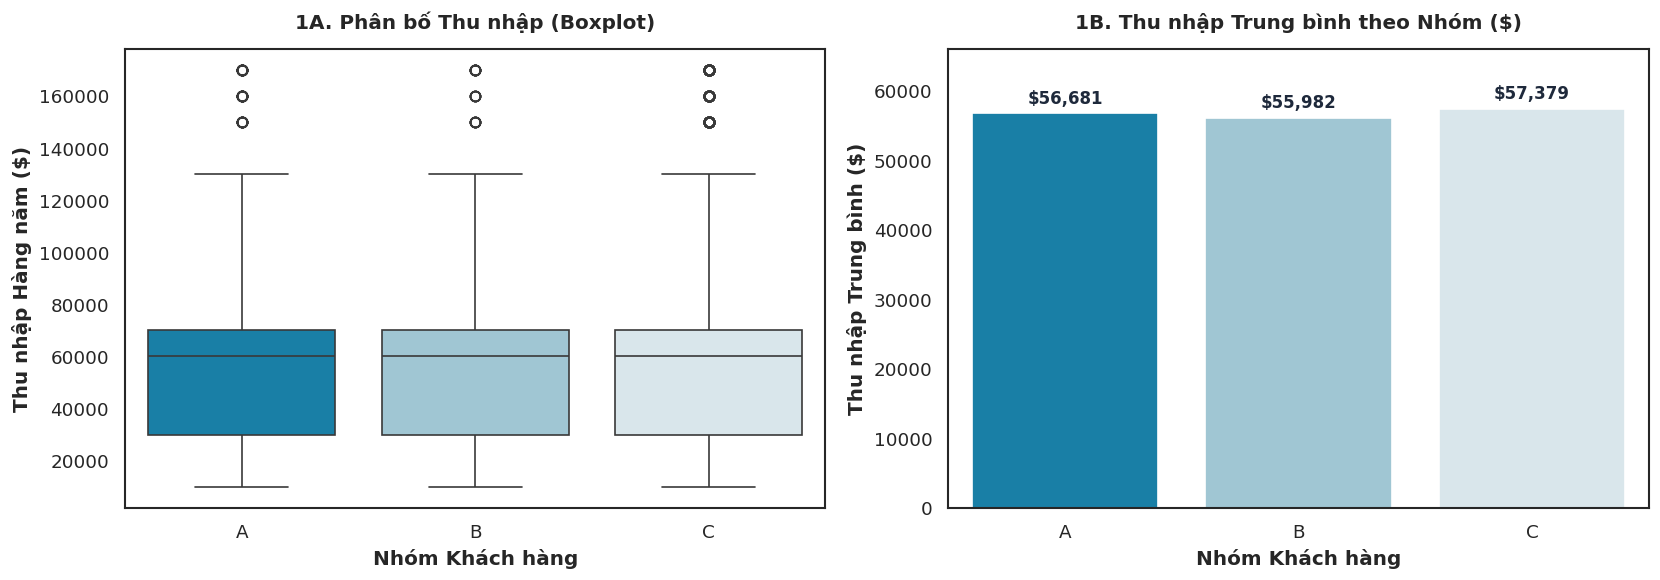

In [ ]:
# @title
# Boxplot So sánh Thu nhập giữa các Nhóm ABC
# 1. Tính Thu nhập trung bình theo từng nhóm ABC
mean_income = (
    df_customer_final.groupby('ABC_Group')['AnnualIncome']
    .mean()
    .reindex(['A', 'B', 'C'])
    .reset_index()
)

# 2. Khởi tạo khung vẽ 2 biểu đồ song song
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
palette=['#018ABE', '#97CADB', '#D6E8EE']

# --- Biểu đồ 1A: Boxplot Phân bố Thu nhập ---
sns.boxplot(
    data=df_customer_final,
    x='ABC_Group',
    y='AnnualIncome',
    order=['A', 'B', 'C'],
    palette=palette,
    ax=axes[0]
)
axes[0].set_title('1A. Phân bố Thu nhập (Boxplot)', fontsize=12, weight='bold', pad=12)
axes[0].set_xlabel('Nhóm Khách hàng', weight='bold')
axes[0].set_ylabel('Thu nhập Hàng năm ($)', weight='bold')

# --- Biểu đồ 1B: Bar Chart Thu nhập Trung bình ---
bars = sns.barplot(
    data=mean_income,
    x='ABC_Group',
    y='AnnualIncome',
    palette=palette,
    ax=axes[1]
)
axes[1].set_title('1B. Thu nhập Trung bình theo Nhóm ($)', fontsize=12, weight='bold', pad=12)
axes[1].set_xlabel('Nhóm Khách hàng', weight='bold')
axes[1].set_ylabel('Thu nhập Trung bình ($)', weight='bold')

# Giới hạn trục Y cao hơn một chút để không bị đè chữ
axes[1].set_ylim(0, mean_income['AnnualIncome'].max() * 1.15)

# Hiển thị số tiền trung bình cụ thể ($) lên đỉnh mỗi cột
for p in bars.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        axes[1].annotate(
            f'${height:,.0f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            xytext=(0, 4), textcoords='offset points',
            fontsize=10, weight='bold', color='#1E293B'
        )

plt.tight_layout()
plt.show()

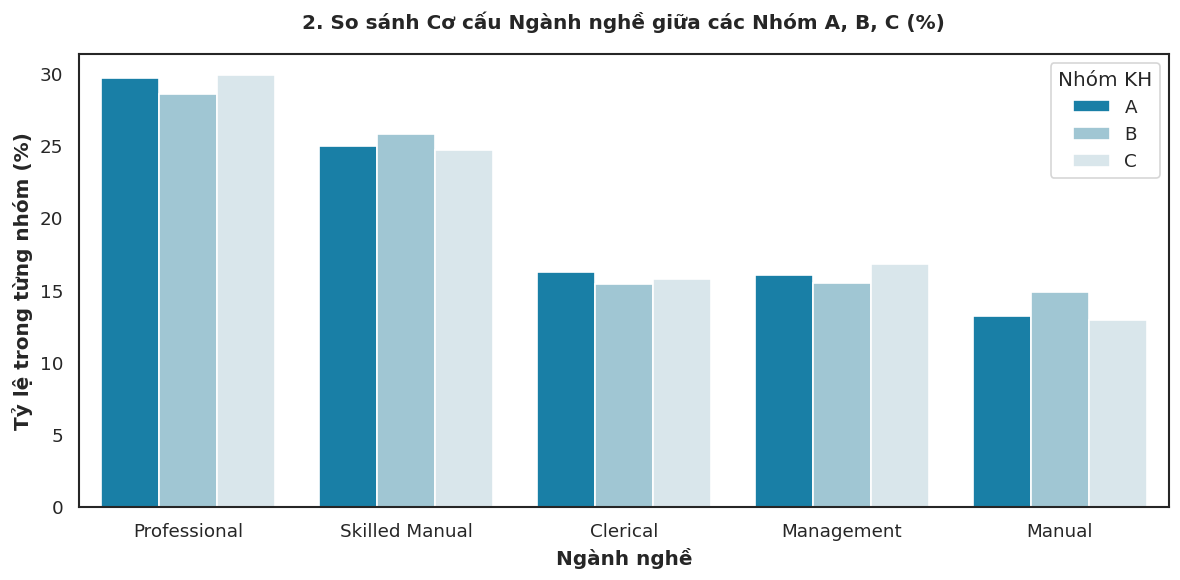

In [ ]:
# @title
# Tính % cơ cấu ngành nghề trong từng nhóm ABC (Chuẩn xác & Không bị lỗi Index)
occ_abc = (
    df_customer_final.groupby('ABC_Group')['Occupation']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

plt.figure(figsize=(10, 5), dpi=120)
bars2 = sns.barplot(
    data=occ_abc,
    x='Occupation',
    y='Percentage',
    hue='ABC_Group',
    hue_order=['A', 'B', 'C'],
    palette=['#018ABE', '#97CADB', '#D6E8EE']
)

plt.title('2. So sánh Cơ cấu Ngành nghề giữa các Nhóm A, B, C (%)', fontsize=12, weight='bold', pad=15)
plt.xlabel('Ngành nghề', weight='bold')
plt.ylabel('Tỷ lệ trong từng nhóm (%)', weight='bold')
plt.legend(title='Nhóm KH', loc='upper right')
plt.tight_layout()
plt.show()

# 6. Đề xuất / Kết luận

## *6.1 Nhóm A chỉ chiếm bao nhiêu % trong tổng số lượng khách hàng? (Có tuân theo quy luật Pareto không?)*

Nhóm A chỉ chiếm **12.9%** tổng số lượng khách hàng *(2,254 / 17,415 khách)*.   Con số trên tuân theo, thậm chí nhỏ hơn cả lý thuyết của quy luật Pareto nhưng đóng góp tới **80.0% tổng lợi nhuận** toàn hệ thống *($852,242)*.

Trái lại, Nhóm C chiếm số 80.1% số lượng khách nhưng chỉ mang về 5.0% tổng lợi nhuận *($53,340)*.

## *6.2 Nếu công ty chỉ có 500 suất quà đặc biệt, danh sách khách hàng nhóm A có vượt quá số lượng này không?*

Khách hàng nhóm A có tận 2,254 khách, gấp 4 lần so với suất phần quà

***Đề xuất***: Không nên tăng thêm suất quà để tặng cho 2,254 khách A. Thay vào đó, có thể lọc top 500 khách hàng tỏng nhóm A thành 1 nhóm S để tặng quà và nuôi dưỡng.

## *6.3 Dựa vào thông tin thu nhập và nghề nghiệp, bạn có đề xuất gì cho chiến dịch Marketing sắp tới để thu hút thêm nhiều khách hàng "Nhóm A" mới?*

###**Insight**
Từ *boxplot* và *bar chart* về thu nhập cho thấy thu nhập của các nhóm là gần như bằng nhau
**-->** **Thu nhập không phải yếu tố quyết định**

Từ barchart về nghề nghiệp cho thấy khách hàng chủ yếu là nhóm "Professional" và "Skilled Manual"
**-->** **Tập trung target vào hai nhóm này**


### **Đề xuất Chiến lược Marketing**

#####*Chuyển dịch sang Target theo Hành vi (Behavioral Targeting)*
- Do nhân khẩu học (Thu nhập & Ngành nghề) giữa 3 nhóm không có sự khác biệt, Marketing không nên lãng phí ngân sách để lọc tệp theo Thu nhập cao hay Ngành nghề cụ thể.
- Nhắm mục tiêu quảng cáo dựa trên Hành vi tiêu dùng: Tần suất tương tác, thói quen chốt đơn nhanh, người có nhu cầu mua các dòng sản phẩm có biên lợi nhuận cao (High-Margin Products).
#####*Sử dụng Tập đối tượng Tương tự (Lookalike Audiences)*
- Xuất danh sách thông tin định danh của 2,254 khách hàng Nhóm A hiện tại để tạo tệp Lookalike 1% trên các nền tảng quảng cáo (Meta Ads, Google Ads). Thuật toán AI của nền tảng sẽ tự động tìm kiếm những người dùng mới có sở thích và hành vi mua sắm giống hệt Nhóm A.
####*Tập trung Nâng hạng Nhóm B*
 - Nhóm B hiện có 1,217 khách hàng (chiếm 7.0%), đang đóng góp 15.0% Lợi nhuận ($159,831) và có mức thu nhập hoàn toàn tương đồng Nhóm A.  
 - Hành động: Triển khai các chiến dịch Combo Cross-sell, gói dịch vụ gia tăng và chương trình Thành viên tích điểm (Loyalty Program) để kích thích Nhóm B gia tăng tần suất mua hàng, từ đó "chạm ngưỡng" và chuyển hóa thành Nhóm A mới.